In [26]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from astroML.datasets import generate_mu_z
from astroML.linear_model import PolynomialRegression
from scipy.stats import mode

In [3]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

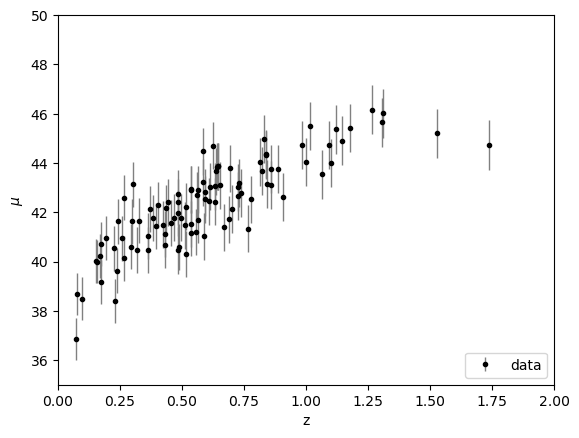

In [4]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [5]:
# linear model
linreg = sklearn.linear_model.LinearRegression()
X = z_sample[:, np.newaxis]
linreg.fit(X, mu_sample, sample_weight=dmu)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


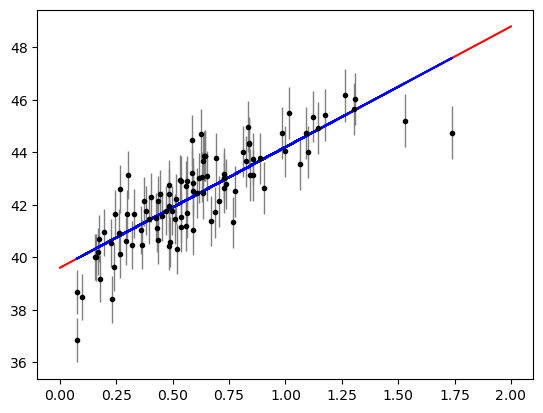

In [6]:
xlin = np.linspace(0, 2, 100)
Xlin = xlin[:, np.newaxis]
ypred = linreg.predict(Xlin)

plt.plot(xlin, ypred, color='red')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X[:, 0], linreg.predict(X), color='blue')

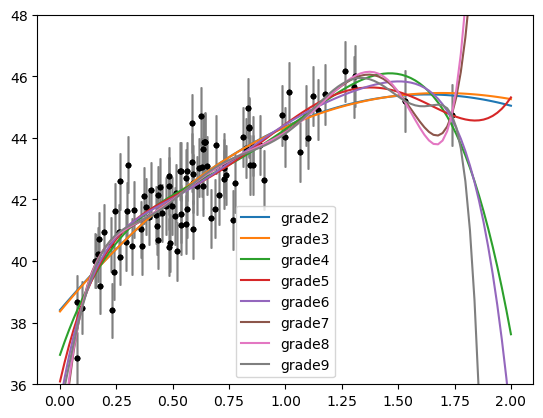

In [7]:
#let's try some different graded polynomials

grades = np.arange(2, 10)

for g in grades:
    polreg = PolynomialRegression(g)
    polreg.fit(X, mu_sample, y_error=dmu)

    ypred = polreg.predict(Xlin)
    plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, zorder=1, alpha=0.5)
    plt.plot(xlin, ypred, label='grade'+str(g), zorder=2)
    plt.ylim(36, 48)
    plt.legend()
    #I think grade 4 is the best

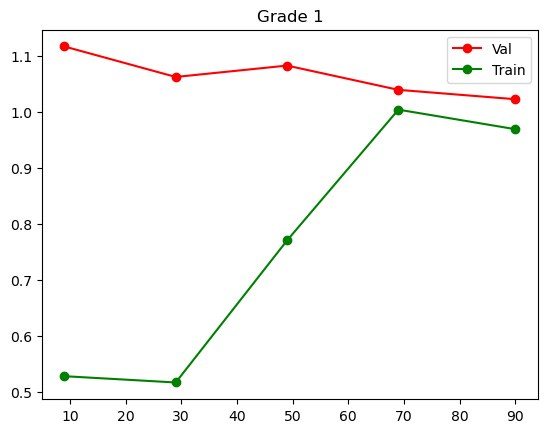

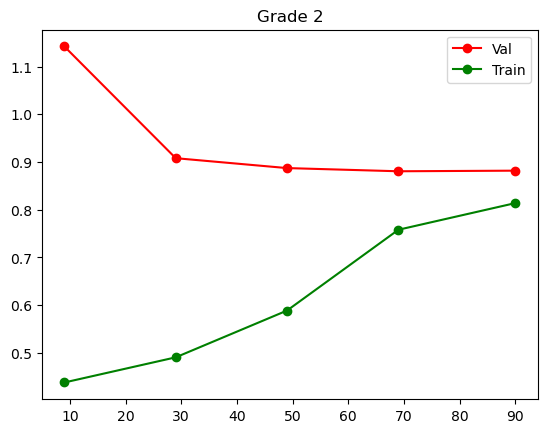

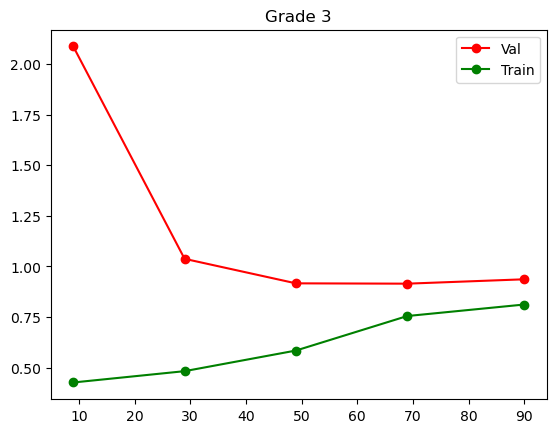

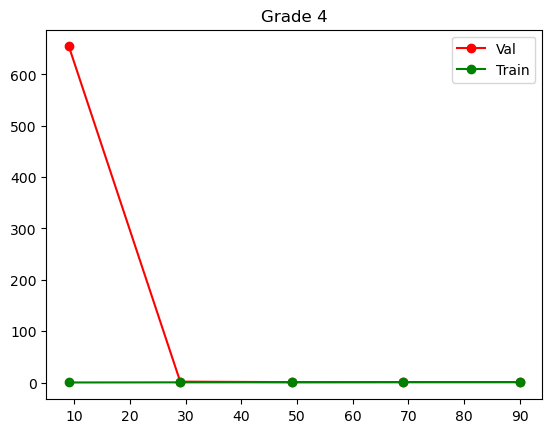

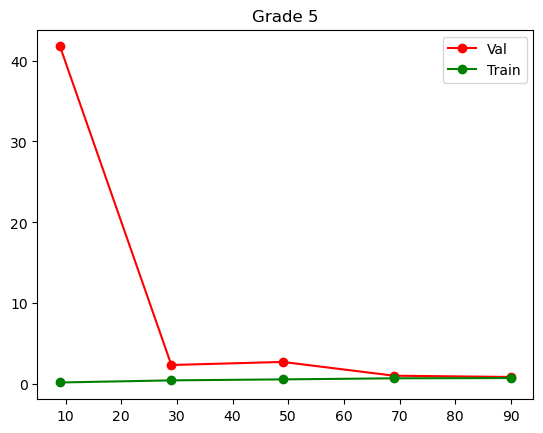

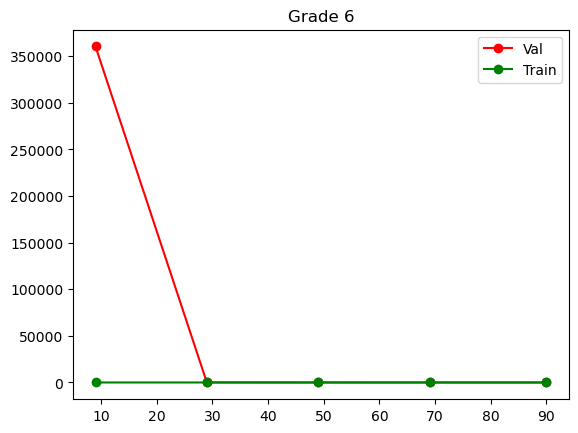

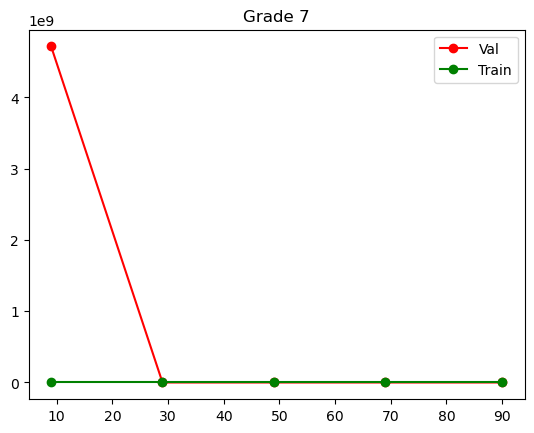

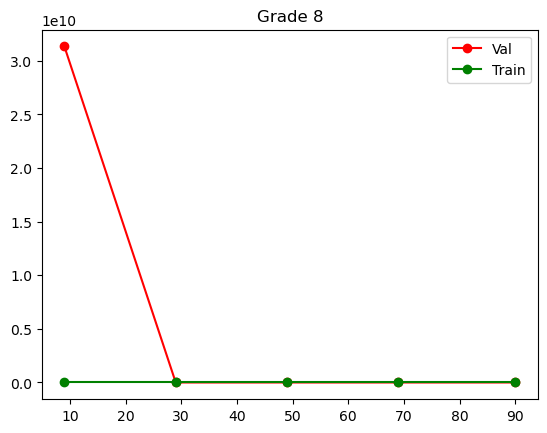

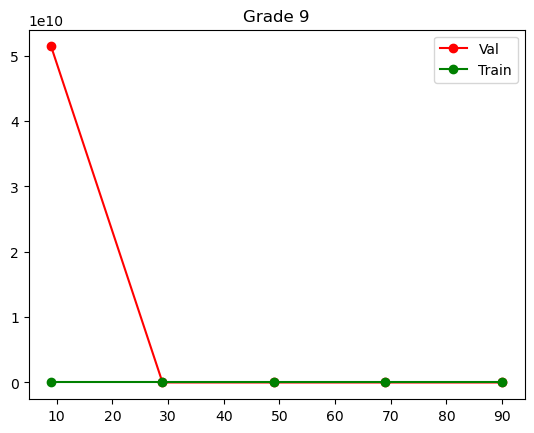

In [8]:
# learning curve

grades = np.arange(1, 10)

for g in grades:
    polreg = PolynomialRegression(g)
    polreg.fit(X, mu_sample, y_error=dmu)
    train_sizes, train_scores_linreg, test_scores_linreg = sklearn.model_selection.learning_curve(polreg, X, mu_sample, scoring="neg_mean_squared_error", cv=10)

    ypred = polreg.predict(Xlin)
    fig, ax = plt.subplots()
    plt.title('Grade '+str(g))
    plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="r", label="Val")
    plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="g", label="Train")
    plt.legend()

    # at grade 4 we already have enough data

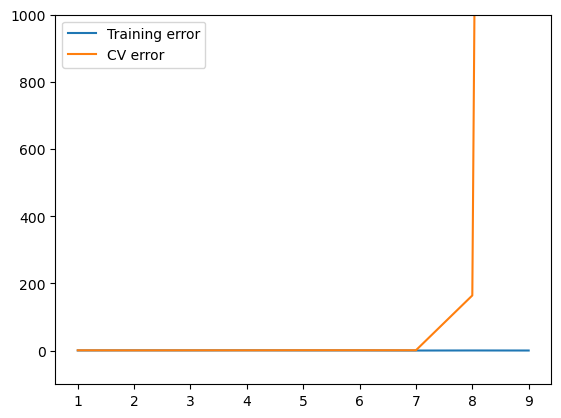

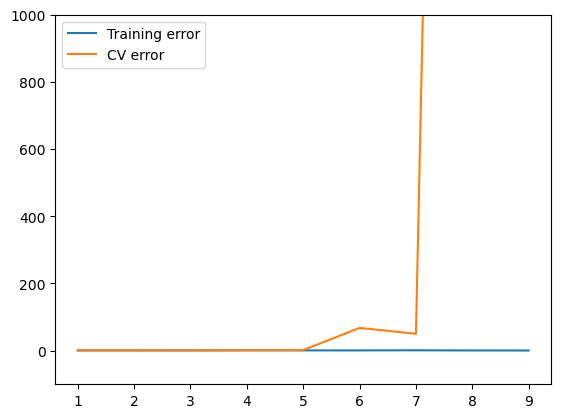

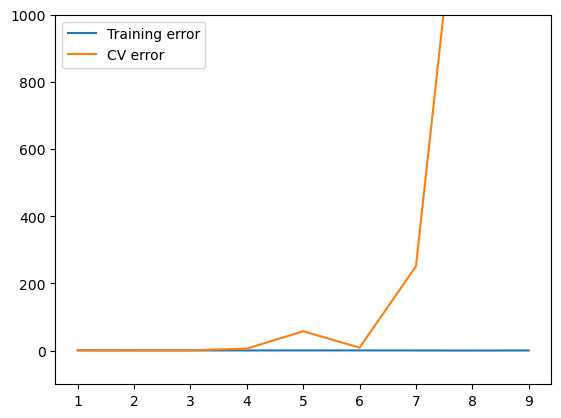

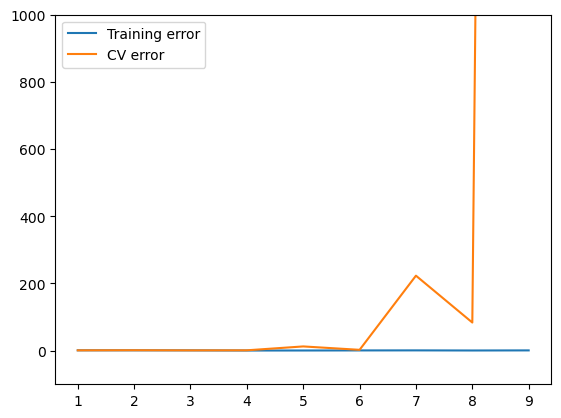

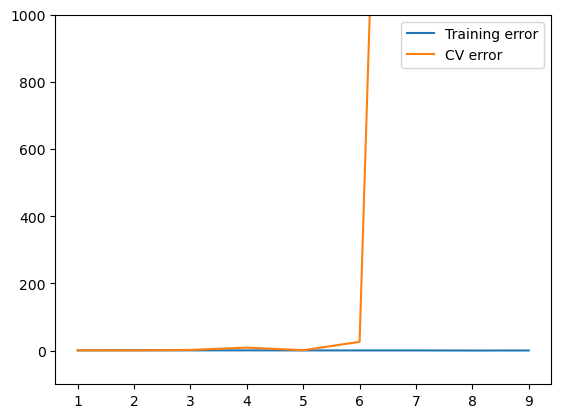

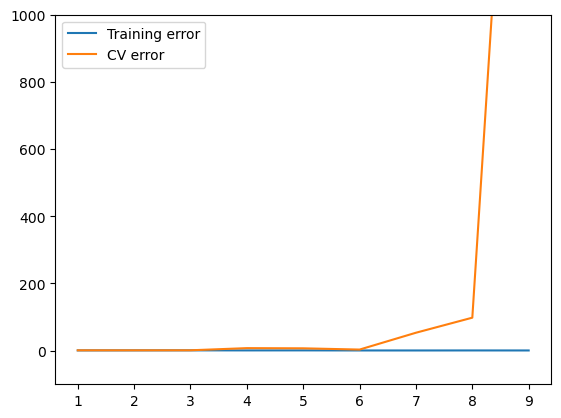

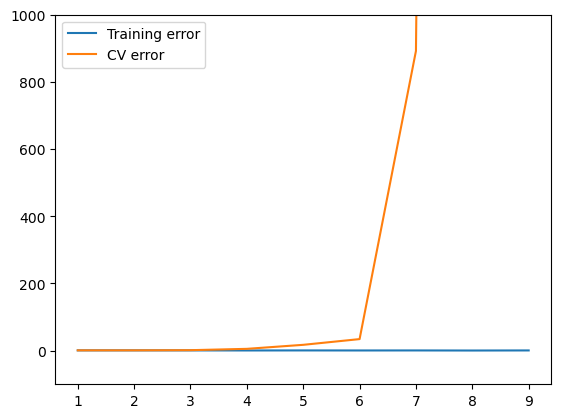

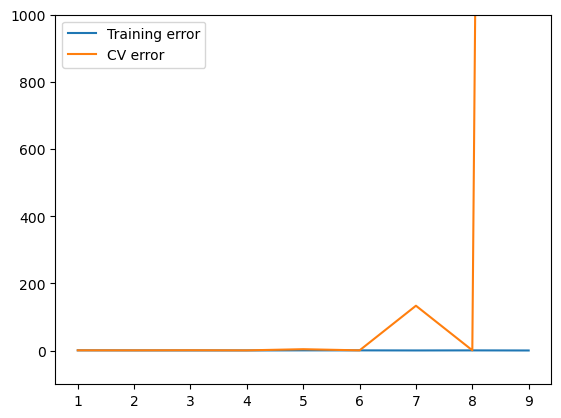

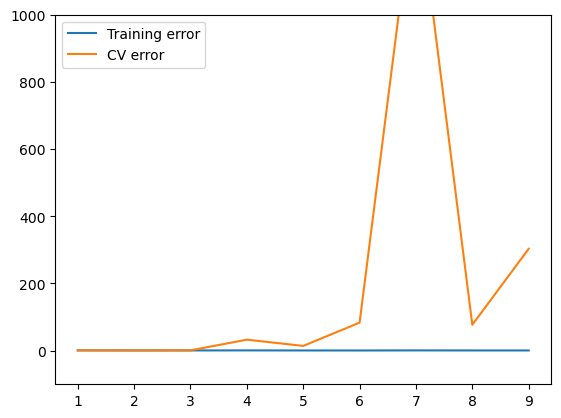

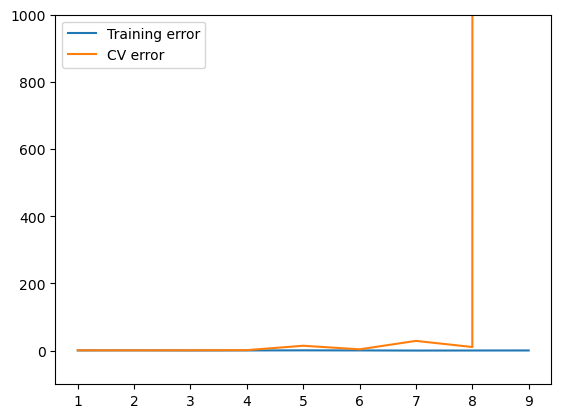

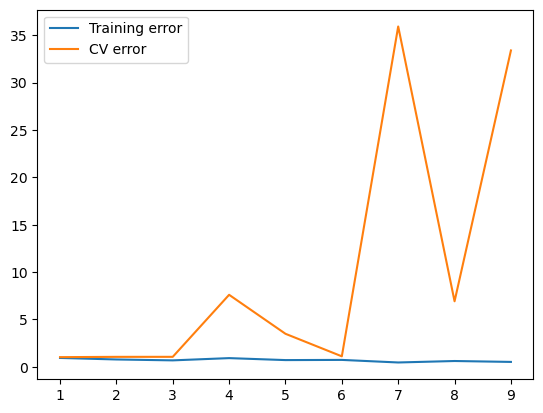

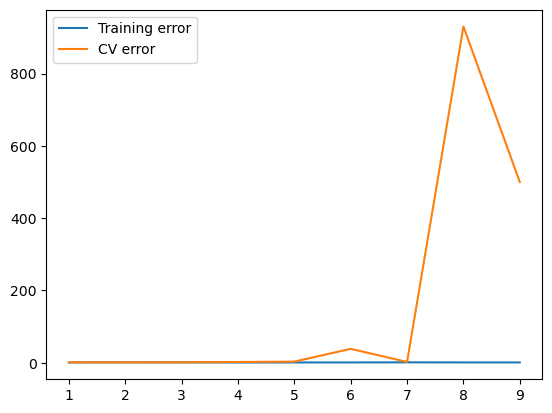

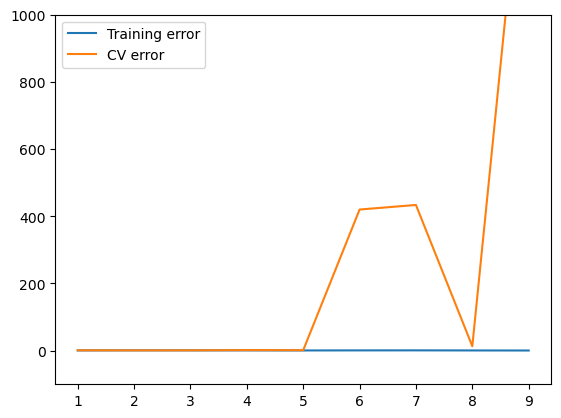

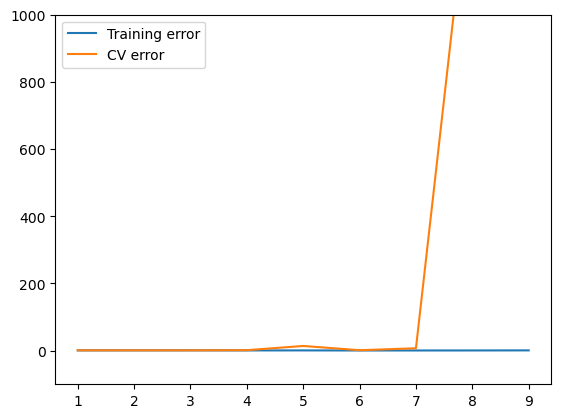

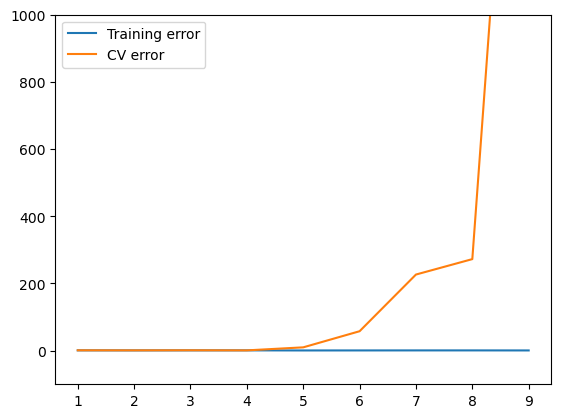

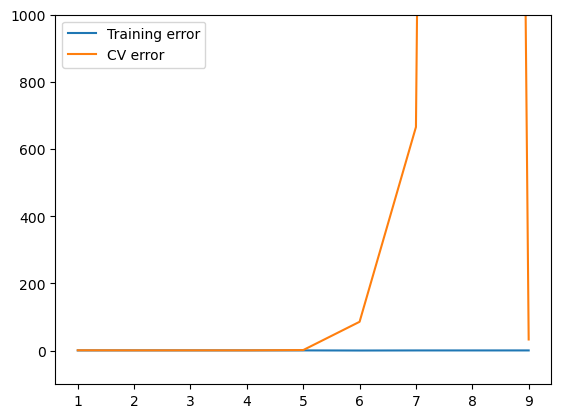

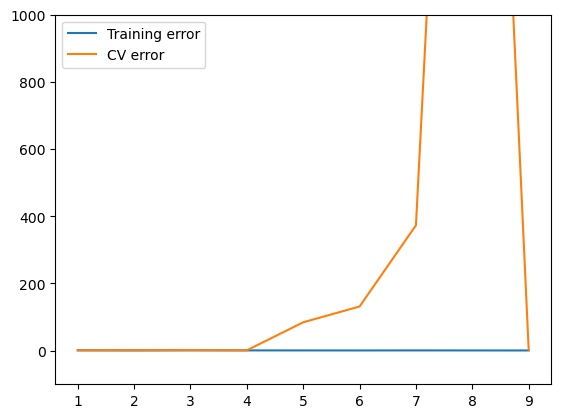

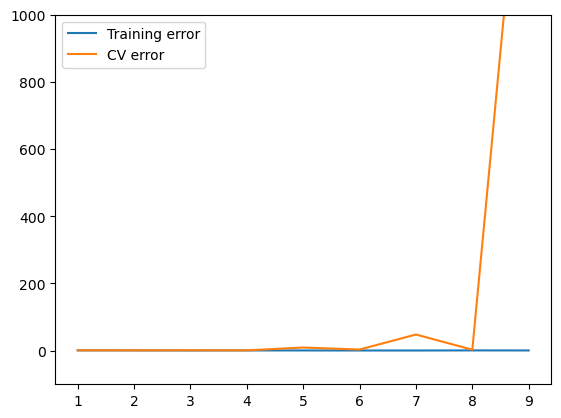

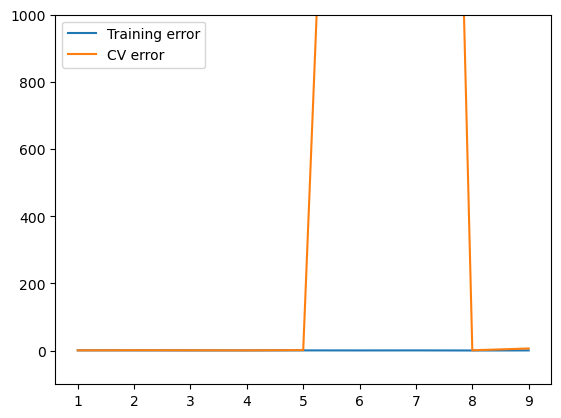

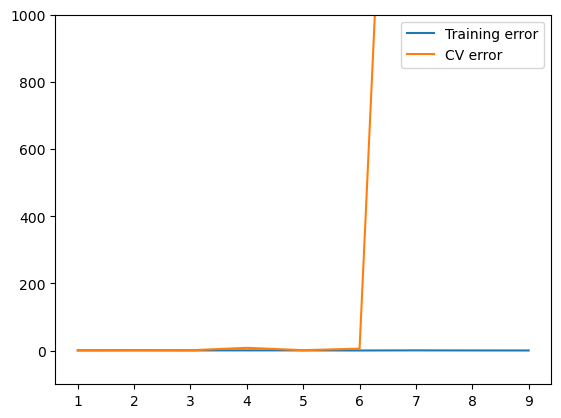

In [34]:
# train test split --> cross validation
# it seems to yield different results each time so I will run it a few times and see what happens most often
# I guess it's anything between 4 and 6 atp

ntime = 20

for i in range(ntime):
    train_errs = []
    cv_errs = []

    for g in grades:
        train_X, cv_X, train_y, cv_y, train_err, cv_err = sklearn.model_selection.train_test_split(X, mu_sample, dmu, test_size=0.8)
        polreg = PolynomialRegression(g)
        polreg.fit(train_X, train_y, y_error=train_err)
    
        trainval = polreg.predict(train_X)
        cvval = polreg.predict(cv_X)
        
        train_err = np.sqrt(np.sum((trainval - train_y) ** 2) / len(train_y))
        train_errs.append(train_err)
    
        cv_err = np.sqrt(np.sum((cvval - cv_y) ** 2)
                              / len(cv_y))
        cv_errs.append(cv_err)

    fig, ax = plt.subplots()
    plt.plot(grades, train_errs, label='Training error')
    plt.plot(grades, cv_errs, label='CV error')
    plt.legend()
    if max(cv_errs) > 1000:
        plt.ylim(-100, 1000)
    # train_errs = np.array(train_errs)
    # cv_errs = np.array(cv_errs)